In [32]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from network import Network

In [33]:
train_df = pd.read_csv("datasets//train_energy_data.csv")
test_df = pd.read_csv("datasets//test_energy_data.csv")

In [34]:
feature_headings = ["Square Footage", "Number of Occupants", "Appliances Used", "Average Temperature"]
target_heading = "Energy Consumption"

X_train = train_df[feature_headings].to_numpy()
Y_train = train_df[target_heading].to_numpy()

X_test = test_df[feature_headings].to_numpy()
Y_test = test_df[target_heading].to_numpy()

X_mean = np.concatenate([X_train, X_test], axis=0).mean(axis=0)
X_std = np.concatenate([X_train, X_test], axis=0).std(axis=0)
Y_mean = np.concatenate([Y_train, Y_test], axis=0).mean(axis=0)
Y_std = np.concatenate([Y_train, Y_test], axis=0).std(axis=0)

x_train = (X_train - X_mean)/X_std
y_train = (Y_train - Y_mean)/Y_std
x_test = (X_test - X_mean)/X_std
y_test = (Y_test - Y_mean)/Y_std

In [35]:
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [36]:
def norm_weights(model):

    wTw = (model.fc_1.weight.data * model.fc_1.weight.data).sum() + \
              (model.fc_1.bias.data * model.fc_1.bias.data).sum() + \
              (model.fc_2.weight.data * model.fc_2.weight.data).sum() + \
              (model.fc_2.bias.data * model.fc_2.bias.data).sum() + \
              (model.fc_3.weight.data * model.fc_3.weight.data).sum() + \
              (model.fc_3.bias.data * model.fc_3.bias.data).sum()

    return wTw

def log_posterior_weights(model, predicts, target, alpha, beta):

    wTw = norm_weights(model)
    TSE = ((predicts - target)**2).sum()
    return -0.5 * (alpha * wTw + beta * TSE)

def grad_weights(model):

    g = torch.cat([model.fc_1.weight.grad.view(-1), model.fc_1.bias.grad.view(-1), 
                   model.fc_2.weight.grad.view(-1), model.fc_2.bias.grad.view(-1), 
                   model.fc_3.weight.grad.view(-1), model.fc_3.bias.grad.view(-1)])
    return g

In [37]:
model = Network(len(feature_headings))
optim = Adam(model.parameters())
alpha = 2.
beta = 2.

batch_size = 64
NUM_EPOCHS = 95
train_dataset = TensorDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

LPW = []
Mean_Squared_Error = []
ALPHA = []
BETA = []

for epoch in range(NUM_EPOCHS):

    print(f"\n\nStarting Epoch {epoch + 1} --\n")

    with torch.enable_grad():
        for batch, xy_batch in enumerate(train_dataloader):

            x_batch, y_batch = xy_batch
            y_hat = model(x_batch).squeeze()
            lpw = log_posterior_weights(model, y_hat, y_batch, alpha, beta)
            LPW.append(lpw.detach())

            optim.zero_grad()
            (-lpw).backward()
            optim.step()

            TSE = ((y_hat - y_batch)**2).sum()
            MSE = TSE / y_batch.size(0)
            Mean_Squared_Error.append(MSE.detach())
            print(f"\tBatch {batch + 1} | MSE -- {MSE.detach():.3f}")

        y_hat = model(x_train).squeeze()

        H = 0
        for idx in range(y_hat.size(0)):
            model.zero_grad()
            y_hat[idx].backward(retain_graph=True)
            g = grad_weights(model)
            H += g * g[..., None]

    with torch.no_grad():
        H_evals = torch.linalg.eigvals(H)
        gamma = (H_evals/(alpha + H_evals)).sum().real

        model.zero_grad()
        wTw = norm_weights(model)
        alpha = gamma/wTw

        TSE = ((y_train - y_hat)**2).sum()
        beta_inv = TSE / (y_train.size(0) - gamma)
        beta = 1/beta_inv

        ALPHA.append(alpha)
        BETA.append(beta)
        print(f"\n\tAlpha -- {alpha:.3f} | Beta -- {beta:.3f}")



Starting Epoch 1 --

	Batch 1 | MSE -- 1.268
	Batch 2 | MSE -- 1.067
	Batch 3 | MSE -- 0.866
	Batch 4 | MSE -- 1.201
	Batch 5 | MSE -- 0.998
	Batch 6 | MSE -- 0.754
	Batch 7 | MSE -- 0.663
	Batch 8 | MSE -- 1.019
	Batch 9 | MSE -- 0.777
	Batch 10 | MSE -- 0.932
	Batch 11 | MSE -- 0.755
	Batch 12 | MSE -- 0.888
	Batch 13 | MSE -- 0.846
	Batch 14 | MSE -- 0.813
	Batch 15 | MSE -- 0.815
	Batch 16 | MSE -- 0.998

	Alpha -- 2.388 | Beta -- 1.134


Starting Epoch 2 --

	Batch 1 | MSE -- 1.048
	Batch 2 | MSE -- 0.933
	Batch 3 | MSE -- 0.731
	Batch 4 | MSE -- 1.048
	Batch 5 | MSE -- 0.816
	Batch 6 | MSE -- 0.610
	Batch 7 | MSE -- 0.565
	Batch 8 | MSE -- 0.882
	Batch 9 | MSE -- 0.674
	Batch 10 | MSE -- 0.723
	Batch 11 | MSE -- 0.626
	Batch 12 | MSE -- 0.754
	Batch 13 | MSE -- 0.709
	Batch 14 | MSE -- 0.703
	Batch 15 | MSE -- 0.711
	Batch 16 | MSE -- 0.866

	Alpha -- 2.401 | Beta -- 1.330


Starting Epoch 3 --

	Batch 1 | MSE -- 0.881
	Batch 2 | MSE -- 0.817
	Batch 3 | MSE -- 0.623
	Batch 4 | 

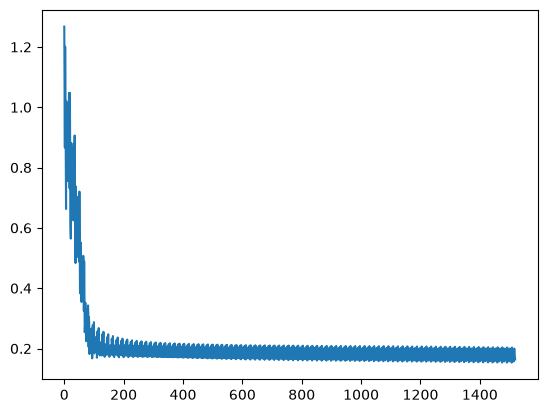

In [40]:
plt.plot(Mean_Squared_Error)

Test mean absolute error: 0.4189344644546509
Average log likelihood: -0.6740570664405823
True mean absolute error: 387.03617674603396


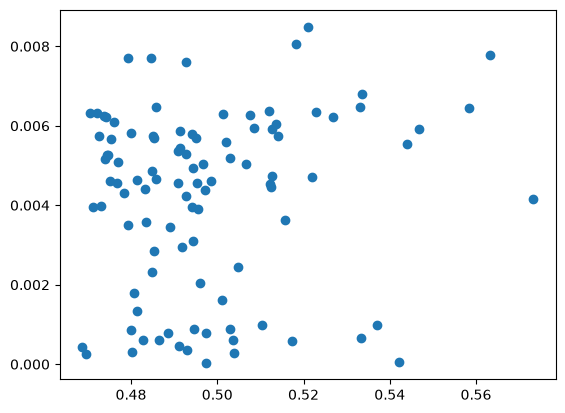

In [41]:
A = alpha * torch.eye(H.size(0)) + beta * H
grads = []

with torch.enable_grad():
    for x in x_test:
        model.zero_grad()
        y_hat = model(x).squeeze()
        y_hat.backward()
        g = grad_weights(model)
        grads.append(g)

y_hat = model(x_test).squeeze().detach()

G = torch.stack(grads)
sigma_2 = 1/beta + (G * (torch.linalg.inv(A) @ G.T).T).sum(dim=1)

test_mae = ((y_hat - y_test).abs())/ y_test.size(0)
print(f"Test mean absolute error: {test_mae.sum()}")

avg_log_likelihood = (-.5 * (torch.log(2 * torch.pi * sigma_2) + ((y_test - y_hat) ** 2)/sigma_2)).mean()
print(f"Average log likelihood: {avg_log_likelihood}")
Y_hat = y_hat.numpy() * Y_std + Y_mean
true_mae = abs(Y_hat - Y_test).sum() / Y_test.shape[0]
print(f"True mean absolute error: {true_mae}")

plt.scatter(torch.sqrt(sigma_2), test_mae)